Скачайте файл с данными о публикациях на сайте Хабрахабр
(https://cloud.mail.ru/public/3ViL/q5xSM1TH2). Выполните следующие действия:

1. Изучите датасет, попробуйте понять какой столбец за что отвечает.

In [ ]:
import pandas as pd

df = pd.read_csv('howpop_train.csv')
df.head()

/var/folders/1w/g7yscm217svfbx_yfc1jwlrh0000gn/T/ipykernel_22639/1237626682.py:4: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('howpop_train.csv')


,url,domain,post_id,published,author,flow,polling,content_len,title,comments,favs,views,votes_plus,votes_minus,views_lognorm,favs_lognorm,comments_lognorm,Unnamed: 17,Unnamed: 18
0,https://habrahabr.ru/post/18284/,habrahabr.ru,18284,2008-01-01 18:19:00,@Tapac,develop,False,4305,Новогодний подарок блоггерам — WordPress 2.3.2,0,0,236.0,0.0,0.0,-0.792687,-1.344075,-2.436871,NaN,NaN
1,https://habrahabr.ru/post/18285/,habrahabr.ru,18285,2008-01-01 18:30:00,@DezmASter,design,False,7344,"Сумасшедшие яйца, или сервис для отслеживания ...",1,1,353.0,1.0,0.0,-0.485214,-0.831946,-1.873193,NaN,NaN
2,https://habrahabr.ru/post/18286/,habrahabr.ru,18286,2008-01-01 18:34:00,@DezmASter,design,False,8431,"Сумасшедшие яйца, или сервис для отслеживания ...",47,72,1200.0,45.0,5.0,0.446090,1.794023,0.574656,NaN,NaN
3,https://habrahabr.ru/post/18291/,habrahabr.ru,18291,2008-01-02 01:32:00,@Taoorus,design,False,5662,"Сглаживание шрифтов, и субпиксельная отрисовка",102,36,5700.0,72.0,3.0,1.627469,1.300050,1.167375,NaN,NaN
4,https://geektimes.ru/post/18294/,geektimes.ru,18294,2008-01-02 14:34:00,@dennydo,NaN,False,3706,Почему мне не нравится iPhone,230,6,1400.0,73.0,15.0,1.362397,0.961094,2.020356,NaN,NaN


2. Удалите столбцы, названия которых заканчиваются на _lognorm. Выберите их с помощью filter() и удалите drop-ом:

In [3]:
df.drop(
    filter(lambda c: c.endswith("_lognorm"), df.columns),
    axis=1, # axis = 1: столбцы
    inplace=True,
) # избавляет от необходимости сохранять датасет

df.head()

,url,domain,post_id,published,author,flow,polling,content_len,title,comments,favs,views,votes_plus,votes_minus,Unnamed: 17,Unnamed: 18
0,https://habrahabr.ru/post/18284/,habrahabr.ru,18284,2008-01-01 18:19:00,@Tapac,develop,False,4305,Новогодний подарок блоггерам — WordPress 2.3.2,0,0,236.0,0.0,0.0,NaN,NaN
1,https://habrahabr.ru/post/18285/,habrahabr.ru,18285,2008-01-01 18:30:00,@DezmASter,design,False,7344,"Сумасшедшие яйца, или сервис для отслеживания ...",1,1,353.0,1.0,0.0,NaN,NaN
2,https://habrahabr.ru/post/18286/,habrahabr.ru,18286,2008-01-01 18:34:00,@DezmASter,design,False,8431,"Сумасшедшие яйца, или сервис для отслеживания ...",47,72,1200.0,45.0,5.0,NaN,NaN
3,https://habrahabr.ru/post/18291/,habrahabr.ru,18291,2008-01-02 01:32:00,@Taoorus,design,False,5662,"Сглаживание шрифтов, и субпиксельная отрисовка",102,36,5700.0,72.0,3.0,NaN,NaN
4,https://geektimes.ru/post/18294/,geektimes.ru,18294,2008-01-02 14:34:00,@dennydo,NaN,False,3706,Почему мне не нравится iPhone,230,6,1400.0,73.0,15.0,NaN,NaN


3. Столбец published (время публикации) содержит строки. Чтобы работать с этими данными как с датой/временем публикации, приведите их к типу datetime:

In [7]:
df["published"] = pd.to_datetime(df.published, yearfirst=True)

df.head()

,url,domain,post_id,published,author,flow,polling,content_len,title,comments,favs,views,votes_plus,votes_minus,Unnamed: 17,Unnamed: 18
0,https://habrahabr.ru/post/18284/,habrahabr.ru,18284,2008-01-01 18:19:00,@Tapac,develop,False,4305,Новогодний подарок блоггерам — WordPress 2.3.2,0,0,236.0,0.0,0.0,NaN,NaN
1,https://habrahabr.ru/post/18285/,habrahabr.ru,18285,2008-01-01 18:30:00,@DezmASter,design,False,7344,"Сумасшедшие яйца, или сервис для отслеживания ...",1,1,353.0,1.0,0.0,NaN,NaN
2,https://habrahabr.ru/post/18286/,habrahabr.ru,18286,2008-01-01 18:34:00,@DezmASter,design,False,8431,"Сумасшедшие яйца, или сервис для отслеживания ...",47,72,1200.0,45.0,5.0,NaN,NaN
3,https://habrahabr.ru/post/18291/,habrahabr.ru,18291,2008-01-02 01:32:00,@Taoorus,design,False,5662,"Сглаживание шрифтов, и субпиксельная отрисовка",102,36,5700.0,72.0,3.0,NaN,NaN
4,https://geektimes.ru/post/18294/,geektimes.ru,18294,2008-01-02 14:34:00,@dennydo,NaN,False,3706,Почему мне не нравится iPhone,230,6,1400.0,73.0,15.0,NaN,NaN


4. Создайте несколько столбцов на основе данных о времени публикации:

In [9]:
df["year"] = [d.year for d in df.published]
df["month"] = [d.month for d in df.published]

df["dayofweek"] = [d.isoweekday() for d in df.published]
df["hour"] = [d.hour for d in df.published]

df.head()

,url,domain,post_id,published,author,flow,polling,content_len,title,comments,favs,views,votes_plus,votes_minus,Unnamed: 17,Unnamed: 18,year,month,dayofweek,hour
0,https://habrahabr.ru/post/18284/,habrahabr.ru,18284,2008-01-01 18:19:00,@Tapac,develop,False,4305,Новогодний подарок блоггерам — WordPress 2.3.2,0,0,236.0,0.0,0.0,NaN,NaN,2008,1,2,18
1,https://habrahabr.ru/post/18285/,habrahabr.ru,18285,2008-01-01 18:30:00,@DezmASter,design,False,7344,"Сумасшедшие яйца, или сервис для отслеживания ...",1,1,353.0,1.0,0.0,NaN,NaN,2008,1,2,18
2,https://habrahabr.ru/post/18286/,habrahabr.ru,18286,2008-01-01 18:34:00,@DezmASter,design,False,8431,"Сумасшедшие яйца, или сервис для отслеживания ...",47,72,1200.0,45.0,5.0,NaN,NaN,2008,1,2,18
3,https://habrahabr.ru/post/18291/,habrahabr.ru,18291,2008-01-02 01:32:00,@Taoorus,design,False,5662,"Сглаживание шрифтов, и субпиксельная отрисовка",102,36,5700.0,72.0,3.0,NaN,NaN,2008,1,3,1
4,https://geektimes.ru/post/18294/,geektimes.ru,18294,2008-01-02 14:34:00,@dennydo,NaN,False,3706,Почему мне не нравится iPhone,230,6,1400.0,73.0,15.0,NaN,NaN,2008,1,3,14


5. Используя Seaborn, постройте визуализацию и покажите в каком месяце (и какого года) было больше всего публикаций.

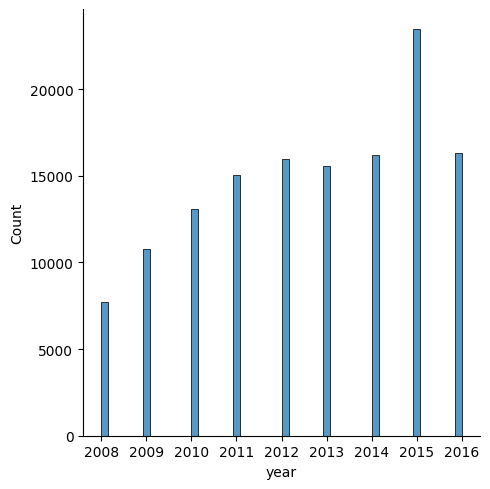

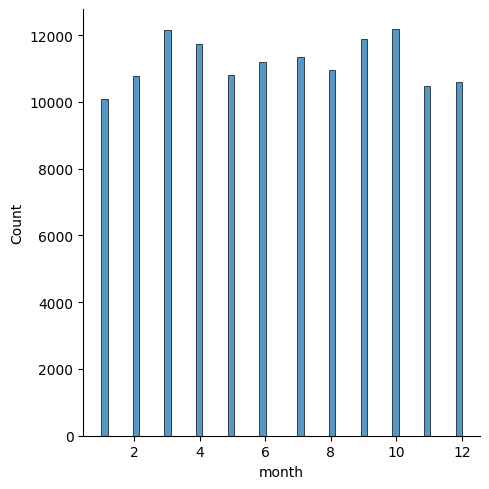

In [10]:
import seaborn as sb

sb.displot(df['year'])
sb.displot(df['month'])

6. Используя Seaborn, постройте график зависимости числа публикаций от дня недели, используя параметр hue.

<Axes: xlabel='day_name', ylabel='count'>

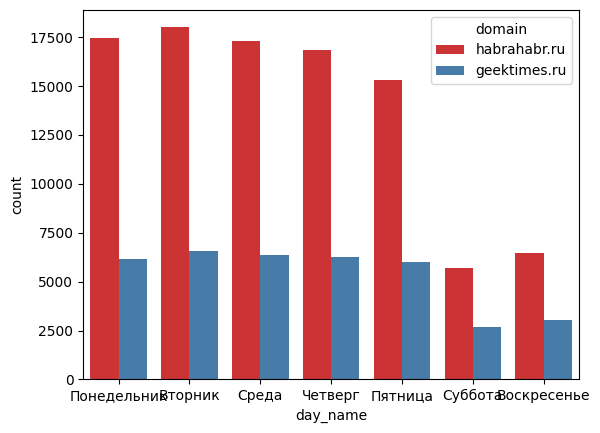

In [11]:
days_map = {
    1: 'Понедельник',
    2: 'Вторник',
    3: 'Среда',
    4: 'Четверг',
    5: 'Пятница',
    6: 'Суббота',
    7: 'Воскресенье'
}
df['day_name'] = df['dayofweek'].map(days_map)

sb.countplot(data=df, x='day_name', hue='domain',
              order=['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье'], palette='Set1')

7. Используя Seaborn, проведите визуальный анализ и отметьте верные утверждения про данный датасет:

    - Больше всего просмотров набирают статьи, опубликованные в 12 часов дня
    - У опубликованных в 10 утра постов больше всего комментариев
    - Больше всего просмотров набирают статьи, опубликованные в 6 часов утра
    - Максимальное число комментариев на гиктаймсе набрала статья, опубликованная в 9 часов вечера
    - На хабре дневные статьи комментируют чаще, чем вечерние

<Axes: xlabel='hour', ylabel='views'>

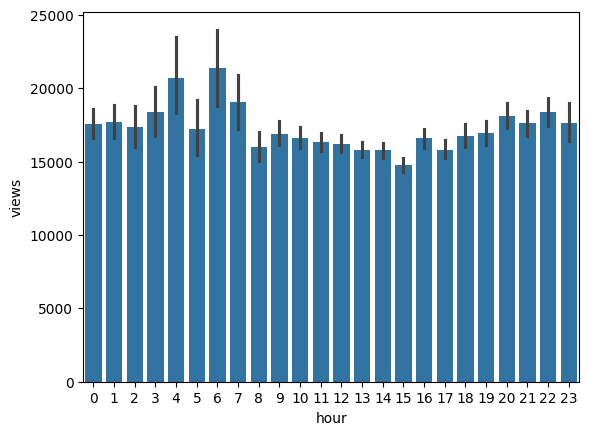

In [12]:
sb.barplot(x = "hour", y = "views", data = df)

<Axes: xlabel='hour', ylabel='comments'>

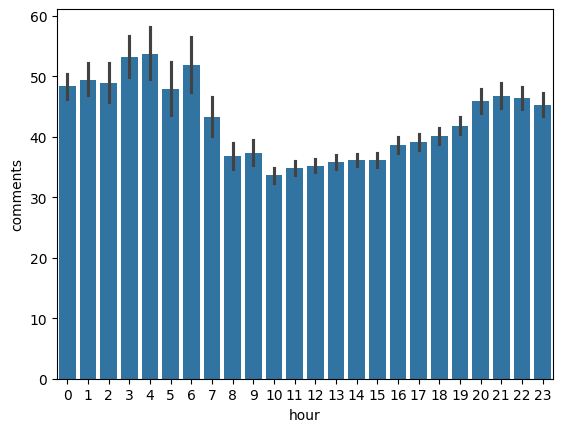

In [13]:
sb.barplot(x = "hour", y = "comments", data = df)

<Axes: xlabel='hour', ylabel='comments'>

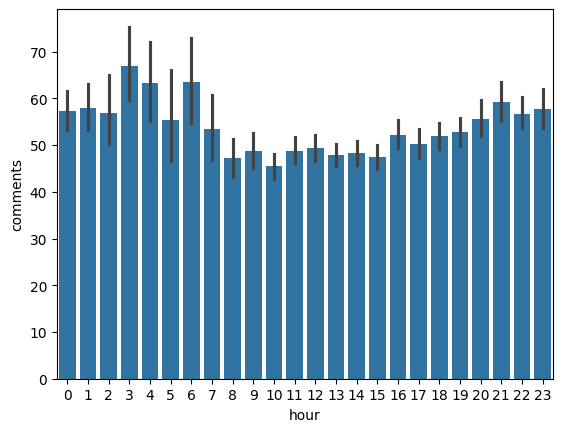

In [14]:
grouped = df.groupby(['hour'])
aggregated = grouped.agg({'comments': 'sum'})
filtered_df_ = df.loc[df['domain'] == 'geektimes.ru']
sb.barplot(x = "hour", y = "comments", data = filtered_df_)

<Axes: xlabel='hour', ylabel='comments'>

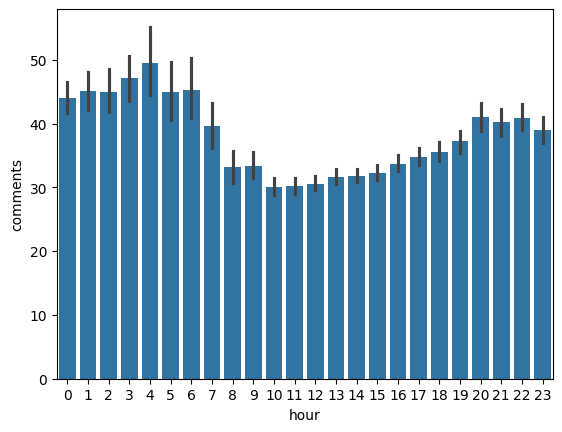

In [15]:
filtered_df = df.loc[df['domain'] == 'habrahabr.ru']
sb.barplot(x = "hour", y = "comments", data = filtered_df)

8. Используя Seaborn, проведите визуальный анализ и определите кого из топ-20 авторов чаще всего минусуют?

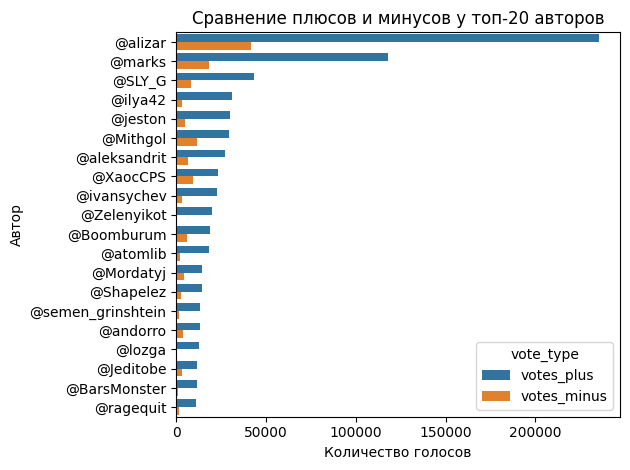

In [18]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values(by='votes_plus', ascending=False)
grouped = df.groupby('author')
aggregated = grouped.agg({
    'votes_plus': 'sum',
    'votes_minus': 'sum'
}).reset_index()

top_20_authors = aggregated.nlargest(20, 'votes_plus')

top_20_by_minus = top_20_authors.sort_values('votes_minus', ascending=False)

top_20_melted = pd.melt(top_20_authors,
                        id_vars=['author'],
                        value_vars=['votes_plus', 'votes_minus'],
                        var_name='vote_type',
                        value_name='count')
sb.barplot(data=top_20_melted, y='author', x='count', hue='vote_type')
plt.title('Сравнение плюсов и минусов у топ-20 авторов')
plt.xlabel('Количество голосов')
plt.ylabel('Автор')
plt.tight_layout()
plt.show()

9. Используя Seaborn, сравните субботы и понедельники. Правда ли, что по субботам авторы пишут в основном днём, а по понедельникам — в основном вечером?

Text(0, 0.5, 'Количество постов')

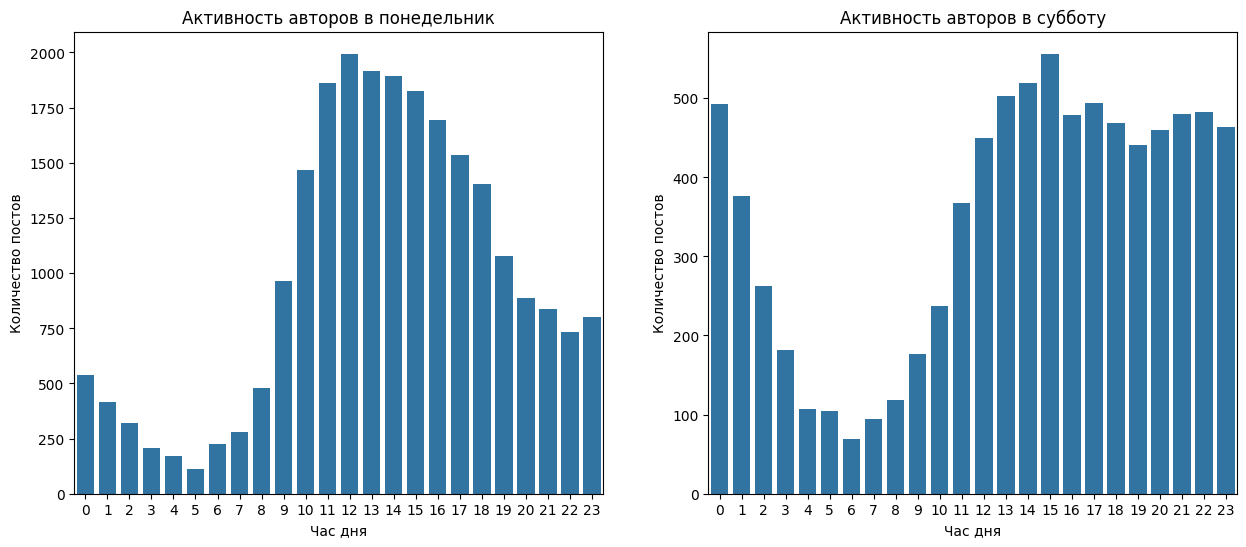

In [19]:
df_mon = df.loc[df['dayofweek'] == 1]
df_sut = df.loc[df['dayofweek'] == 6]

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sb.countplot(data=df_mon, x='hour')
plt.title('Активность авторов в понедельник')
plt.xlabel('Час дня')
plt.ylabel('Количество постов')

plt.subplot(1, 2, 2)
sb.countplot(data=df_sut, x='hour')
plt.title('Активность авторов в субботу')
plt.xlabel('Час дня')
plt.ylabel('Количество постов')